In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, "..")

import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 40)
os.makedirs("figures/model", exist_ok=True)
os.makedirs("./data/processed", exist_ok=True)
os.makedirs("./models", exist_ok=True)
warnings.filterwarnings("ignore", category=UserWarning)
%matplotlib inline

In [2]:
station_day_df = pd.read_parquet("./data/processed/road_station_day_dataset.parquet")
station_day_df["planned_date"] = pd.to_datetime(station_day_df["planned_date"])

print(f"Loaded: {len(station_day_df):,} station-day rows")
print(f"Unique stations: {station_day_df['station_name'].nunique():,}")
print(f"Date range: {station_day_df['planned_date'].min().date()} – {station_day_df['planned_date'].max().date()}")
print(f"\nColumns: {list(station_day_df.columns)}")
print(f"\nRows with closure:    {station_day_df['has_road_closure'].sum():,}")
print(f"Rows without closure: {(station_day_df['has_road_closure'] == 0).sum():,}")
station_day_df.head()

Loaded: 5,300 station-day rows
Unique stations: 2,299
Date range: 2026-04-03 – 2026-04-12

Columns: ['station_name', 'stanox', 'planned_date', 'train_movements', 'mean_delay_minutes', 'median_delay_minutes', 'late_movements', 'mean_late_minutes', 'median_late_minutes', 'max_late_minutes', 'early_movements', 'mean_early_minutes', 'median_early_minutes', 'max_early_minutes', 'delayed_movements_5min', 'severe_delay_movements_15min', 'late_share', 'early_share', 'delayed_share_5min', 'severe_delay_share_15min', 'road_closure_count', 'min_distance_km', 'mean_distance_km', 'max_effective_duration_hours', 'mean_effective_duration_hours', 'inv_distance_sum', 'n_unplanned_closures', 'has_road_closure', 'day_of_week', 'is_weekend']

Rows with closure:    3,323.0
Rows without closure: 1,977


,station_name,stanox,planned_date,train_movements,mean_delay_minutes,median_delay_minutes,late_movements,mean_late_minutes,median_late_minutes,max_late_minutes,early_movements,mean_early_minutes,median_early_minutes,max_early_minutes,delayed_movements_5min,severe_delay_movements_15min,late_share,early_share,delayed_share_5min,severe_delay_share_15min,road_closure_count,min_distance_km,mean_distance_km,max_effective_duration_hours,mean_effective_duration_hours,inv_distance_sum,n_unplanned_closures,has_road_closure,day_of_week,is_weekend
0,Abbey Wood,88601,2026-04-10,15,0.566667,-0.50,5,1.133333,0.0,12.0,9,0.566667,0.50,1.5,1,0,0.333333,0.6,0.066667,0.0,7.0,10.191189,18.115876,6.5,2.357143,0.414091,4.0,1.0,4,0
1,Abbey Wood,88601,2026-04-11,2,-0.750000,-0.75,0,0.000000,0.0,0.0,2,0.750000,0.75,1.0,0,0,0.000000,1.0,0.000000,0.0,3.0,13.397358,18.104797,8.0,4.916667,0.176387,1.0,1.0,5,1
2,Abbey Wood,88601,2026-04-12,3,1.500000,0.50,3,1.500000,0.5,3.5,0,0.000000,0.00,0.0,0,0,1.000000,0.0,0.000000,0.0,2.0,15.067826,19.788112,8.0,4.125000,0.107169,1.0,1.0,6,1
3,Aber,78371,2026-04-10,4,2.625000,2.00,2,3.125000,2.5,7.5,2,0.500000,0.50,1.0,1,0,0.500000,0.5,0.250000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,4,0
4,Aber,78371,2026-04-11,2,-0.500000,-0.50,0,0.000000,0.0,0.0,2,0.500000,0.50,0.5,0,0,0.000000,1.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,5,1


Threshold: mean delay > 5 min
Not disrupted (0): 4,999
Disrupted     (1): 301
Disruption rate:   5.68%


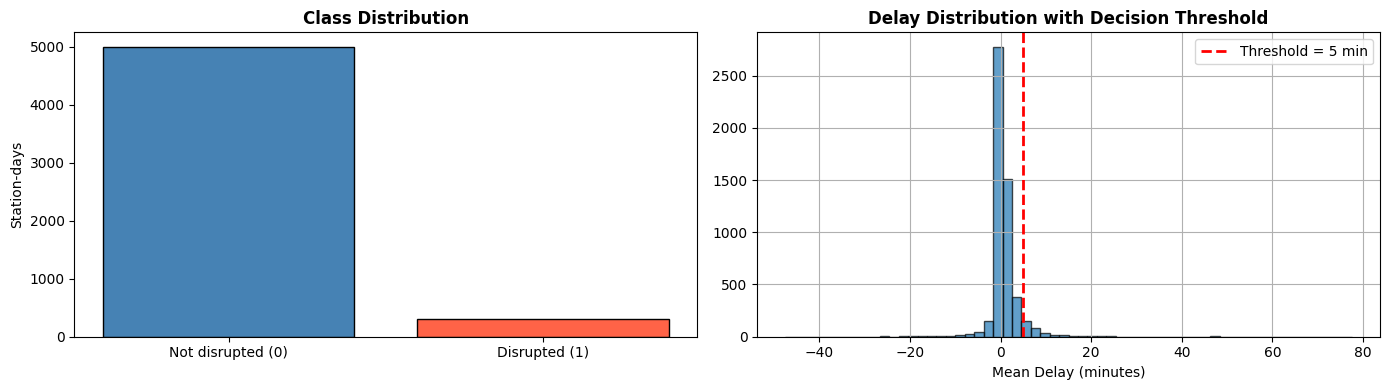

In [3]:
DISRUPTION_THRESHOLD = 5  # minutes

station_day_df["disrupted"] = (
    station_day_df["mean_delay_minutes"] > DISRUPTION_THRESHOLD
).astype(int)

counts = station_day_df["disrupted"].value_counts()
rate   = station_day_df["disrupted"].mean()
print(f"Threshold: mean delay > {DISRUPTION_THRESHOLD} min")
print(f"Not disrupted (0): {counts.get(0, 0):,}")
print(f"Disrupted     (1): {counts.get(1, 0):,}")
print(f"Disruption rate:   {rate:.2%}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(["Not disrupted (0)", "Disrupted (1)"], [counts.get(0,0), counts.get(1,0)],
            color=["steelblue", "tomato"], edgecolor="black")
axes[0].set_title("Class Distribution", fontweight="bold")
axes[0].set_ylabel("Station-days")

station_day_df["mean_delay_minutes"].hist(bins=60, ax=axes[1], edgecolor="black", alpha=0.7)
axes[1].axvline(DISRUPTION_THRESHOLD, color="red", linestyle="--", lw=2,
                label=f"Threshold = {DISRUPTION_THRESHOLD} min")
axes[1].set_xlabel("Mean Delay (minutes)")
axes[1].set_title("Delay Distribution with Decision Threshold", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.savefig("figures/model/class_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

In [4]:
station_day_df["day_of_week"] = station_day_df["planned_date"].dt.dayofweek  # 0=Mon
station_day_df["is_weekend"]   = station_day_df["day_of_week"].isin([5, 6]).astype(int)
station_day_df["is_monday"]    = (station_day_df["day_of_week"] == 0).astype(int)
station_day_df["is_friday"]    = (station_day_df["day_of_week"] == 4).astype(int)

print("Disruption rate by day of week:")
dow_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
dow_stats = (
    station_day_df.groupby("day_of_week")["disrupted"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "disruption_rate", "count": "n_days"})
)
dow_stats.index = [dow_labels[i] for i in dow_stats.index]
print(dow_stats.round(3))

Disruption rate by day of week:
     disruption_rate  n_days
Wed            0.000       1
Thu            0.409      22
Fri            0.066    2205
Sat            0.042    1344
Sun            0.052    1728


In [5]:
BASE_FEATURES = [
    # Closure presence / severity
    "has_road_closure",
    "road_closure_count",
    "min_distance_km",
    "mean_distance_km",
    "max_effective_duration_hours",
    "mean_effective_duration_hours",
    "inv_distance_sum",
    # Planned vs unplanned split
    "n_unplanned_closures",
    # Temporal context
    "day_of_week",
    "is_weekend",
    "is_monday",
    "is_friday",
    # Service volume proxy
    "train_movements",
]

# Keep only columns that exist in the loaded dataframe
features = [f for f in BASE_FEATURES if f in station_day_df.columns]
missing  = [f for f in BASE_FEATURES if f not in station_day_df.columns]
if missing:
    print(f"WARNING: missing features (re-run eda_05_01 to generate them): {missing}")

TARGET = "disrupted"

df_model = (
    station_day_df[features + [TARGET, "planned_date"]]
    .dropna(subset=features)
    .sort_values("planned_date")
    .reset_index(drop=True)
)

split_idx = int(len(df_model) * 0.8)
X_train = df_model.iloc[:split_idx][features]
X_test  = df_model.iloc[split_idx:][features]
y_train = df_model.iloc[:split_idx][TARGET]
y_test  = df_model.iloc[split_idx:][TARGET]

print(f"Features used ({len(features)}): {features}")
print(f"\nTrain: {len(X_train):,} rows — disruption rate: {y_train.mean():.2%}")
print(f"Test:  {len(X_test):,} rows  — disruption rate: {y_test.mean():.2%}")

Features used (13): ['has_road_closure', 'road_closure_count', 'min_distance_km', 'mean_distance_km', 'max_effective_duration_hours', 'mean_effective_duration_hours', 'inv_distance_sum', 'n_unplanned_closures', 'day_of_week', 'is_weekend', 'is_monday', 'is_friday', 'train_movements']

Train: 4,240 rows — disruption rate: 5.71%
Test:  1,060 rows  — disruption rate: 5.57%


In [6]:
from sklearn.linear_model  import LogisticRegression
from sklearn.ensemble       import RandomForestClassifier, GradientBoostingClassifier
from xgboost                import XGBClassifier
from sklearn.pipeline       import Pipeline
from sklearn.preprocessing  import StandardScaler
from sklearn.metrics        import (
    f1_score, average_precision_score, roc_auc_score,
    confusion_matrix, classification_report, precision_recall_curve,
)
import time as timer

# Compute class imbalance ratio for XGBoost scale_pos_weight
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
spw = neg / pos if pos > 0 else 1.0
print(f"Train class ratio (neg/pos): {spw:.2f}  → used as scale_pos_weight for XGBoost")

models = {
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            class_weight="balanced", max_iter=1000, random_state=42
        )),
    ]),
    "RandomForest": RandomForestClassifier(
        n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=4,
        subsample=0.8, random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=spw,
        objective="binary:logistic", eval_metric="aucpr",
        random_state=42, verbosity=0,
    ),
}

# LightGBM (optional)
try:
    from lightgbm import LGBMClassifier
    models["LightGBM"] = LGBMClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        class_weight="balanced", random_state=42, verbose=-1,
    )
    print("LightGBM available — included.")
except ImportError:
    print("LightGBM not installed — skipped (pip install lightgbm to add it).")

print(f"\nModels to evaluate: {list(models.keys())}")

Train class ratio (neg/pos): 16.52  → used as scale_pos_weight for XGBoost
LightGBM not installed — skipped (pip install lightgbm to add it).

Models to evaluate: ['LogisticRegression', 'RandomForest', 'GradientBoosting', 'XGBoost']


In [7]:
results = []

for name, model_obj in models.items():
    t0 = timer.time()
    model_obj.fit(X_train, y_train)
    elapsed = timer.time() - t0

    y_pred  = model_obj.predict(X_test)
    y_proba = (
        model_obj.predict_proba(X_test)[:, 1]
        if hasattr(model_obj, "predict_proba")
        else y_pred.astype(float)
    )

    results.append({
        "model":     name,
        "F1":        f1_score(y_test, y_pred, zero_division=0),
        "PR_AUC":    average_precision_score(y_test, y_proba),
        "ROC_AUC":   roc_auc_score(y_test, y_proba),
        "train_sec": elapsed,
        "_model":    model_obj,
        "_y_pred":   y_pred,
        "_y_proba":  y_proba,
    })
    print(f"{name:<22} F1={results[-1]['F1']:.3f}  PR-AUC={results[-1]['PR_AUC']:.3f}  "
          f"ROC-AUC={results[-1]['ROC_AUC']:.3f}  ({elapsed:.1f}s)")

results_df = pd.DataFrame(results).sort_values("PR_AUC", ascending=False)
display(results_df[["model","F1","PR_AUC","ROC_AUC","train_sec"]].reset_index(drop=True))

LogisticRegression     F1=0.042  PR-AUC=0.060  ROC-AUC=0.539  (0.0s)
RandomForest           F1=0.109  PR-AUC=0.058  ROC-AUC=0.501  (0.3s)
GradientBoosting       F1=0.000  PR-AUC=0.062  ROC-AUC=0.513  (1.0s)
XGBoost                F1=0.114  PR-AUC=0.079  ROC-AUC=0.515  (0.1s)


,model,F1,PR_AUC,ROC_AUC,train_sec
0,XGBoost,0.113684,0.079203,0.514807,0.141423
1,GradientBoosting,0.000000,0.061551,0.512665,0.951253
2,LogisticRegression,0.041667,0.060174,0.538504,0.035190
3,RandomForest,0.108696,0.057517,0.500838,0.286248


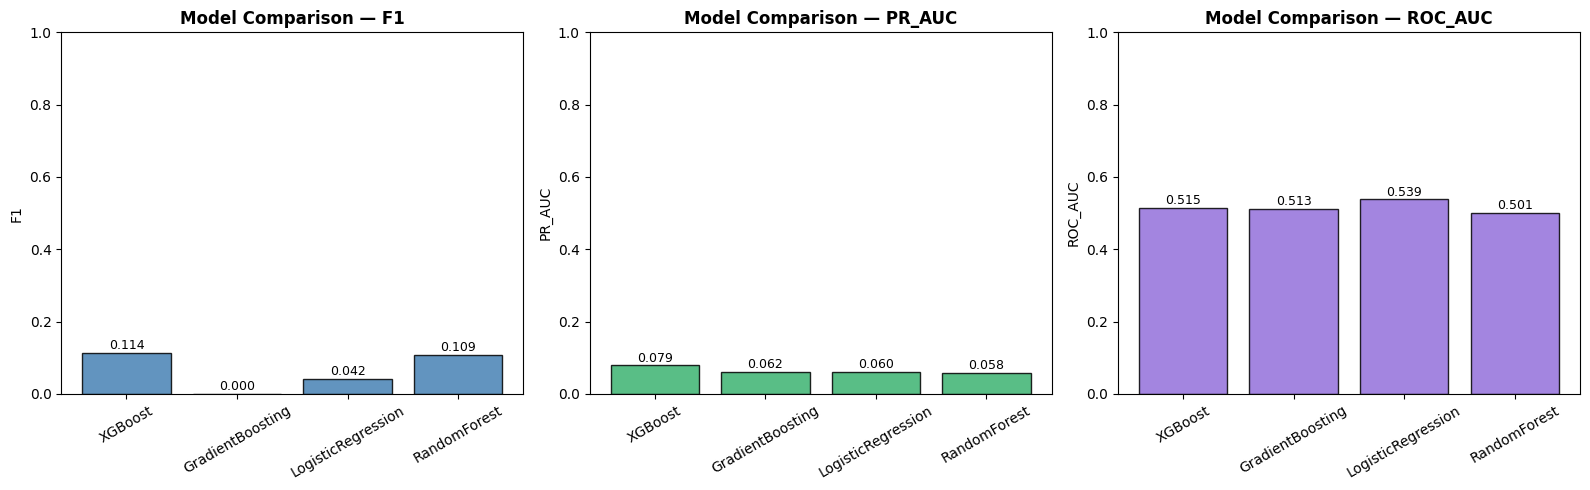

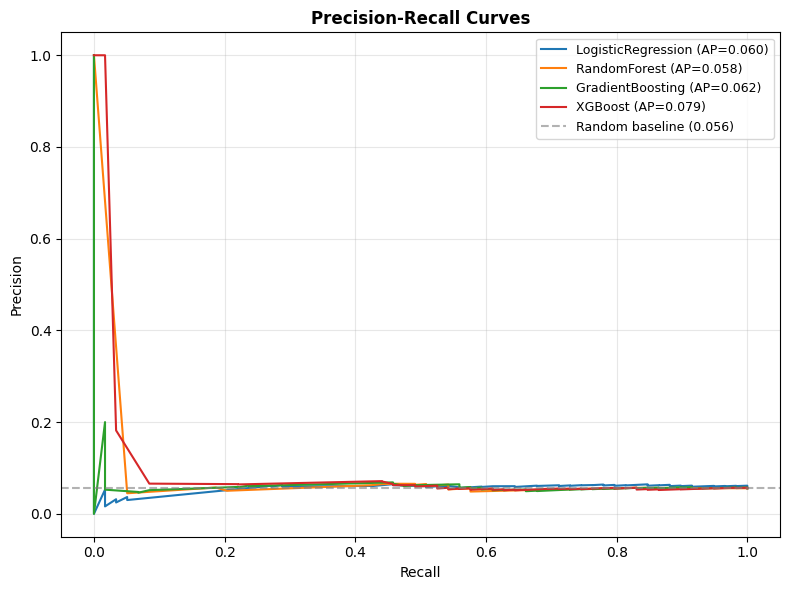

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric, color in [
    (axes[0], "F1",      "steelblue"),
    (axes[1], "PR_AUC",  "mediumseagreen"),
    (axes[2], "ROC_AUC", "mediumpurple"),
]:
    ax.bar(results_df["model"], results_df[metric], color=color, edgecolor="black", alpha=0.85)
    ax.set_title(f"Model Comparison — {metric}", fontweight="bold")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=30)
    ax.set_ylim(0, 1)
    for i, v in enumerate(results_df[metric]):
        ax.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("figures/model/model_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

# Precision-Recall curves for all models
plt.figure(figsize=(8, 6))
for row in results:
    p, r, _ = precision_recall_curve(y_test, row["_y_proba"])
    plt.plot(r, p, label=f"{row['model']} (AP={row['PR_AUC']:.3f})")
baseline = y_test.mean()
plt.axhline(baseline, color="grey", linestyle="--", alpha=0.6, label=f"Random baseline ({baseline:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves", fontweight="bold")
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/model/precision_recall_curves.png", dpi=200, bbox_inches="tight")
plt.show()


GradientBoosting:
               precision    recall  f1-score   support

Not disrupted       0.94      1.00      0.97      1001
    Disrupted       0.00      0.00      0.00        59

     accuracy                           0.94      1060
    macro avg       0.47      0.50      0.49      1060
 weighted avg       0.89      0.94      0.92      1060


XGBoost:
               precision    recall  f1-score   support

Not disrupted       0.95      0.61      0.74      1001
    Disrupted       0.06      0.46      0.11        59

     accuracy                           0.60      1060
    macro avg       0.51      0.53      0.43      1060
 weighted avg       0.90      0.60      0.71      1060



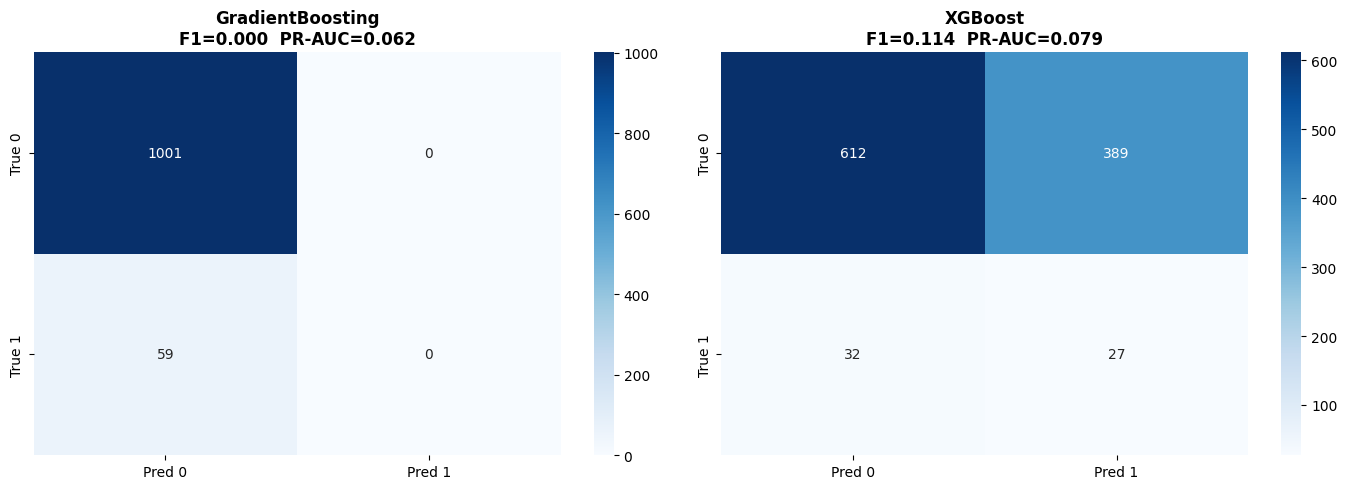

In [9]:
top2 = results_df.head(2)["model"].tolist()
top2_rows = [r for r in results if r["model"] in top2]

fig, axes = plt.subplots(1, len(top2_rows), figsize=(7 * len(top2_rows), 5))
if len(top2_rows) == 1:
    axes = [axes]

for ax, row in zip(axes, top2_rows):
    cm = confusion_matrix(y_test, row["_y_pred"])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=ax,
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["True 0", "True 1"],
    )
    ax.set_title(f"{row['model']}\nF1={row['F1']:.3f}  PR-AUC={row['PR_AUC']:.3f}",
                 fontweight="bold")
    print(f"\n{row['model']}:")
    print(classification_report(y_test, row["_y_pred"], target_names=["Not disrupted", "Disrupted"]))

plt.tight_layout()
plt.savefig("figures/model/confusion_matrices.png", dpi=200, bbox_inches="tight")
plt.show()

Best model: XGBoost  (PR-AUC=0.079, F1=0.114)


C:\Users\patil\AppData\Local\Temp\ipykernel_25020\1541300621.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df, x="importance", y="feature", palette="viridis")


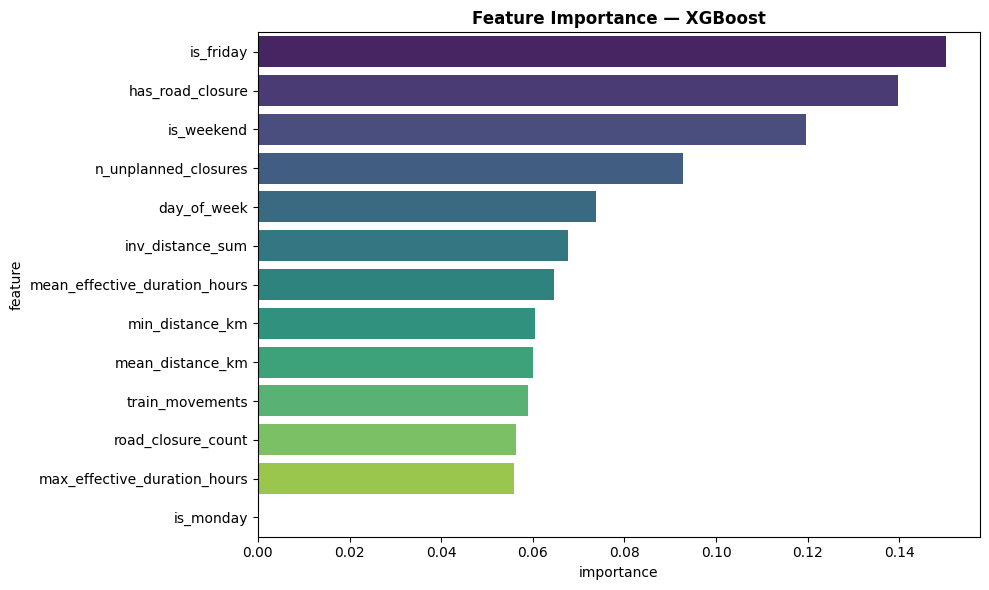

,feature,importance
11,is_friday,0.150107
0,has_road_closure,0.139788
9,is_weekend,0.119542
7,n_unplanned_closures,0.092824
8,day_of_week,0.073711
6,inv_distance_sum,0.067693
5,mean_effective_duration_hours,0.064639
2,min_distance_km,0.060462
3,mean_distance_km,0.059964
12,train_movements,0.059032


In [10]:
best_row = results_df.iloc[0]
best_model = best_row["_model"]
best_name  = best_row["model"]
print(f"Best model: {best_name}  (PR-AUC={best_row['PR_AUC']:.3f}, F1={best_row['F1']:.3f})")

# Extract inner estimator from Pipeline if needed
inner = best_model.named_steps["clf"] if hasattr(best_model, "named_steps") else best_model

if hasattr(inner, "feature_importances_"):
    imp_df = pd.DataFrame({"feature": features, "importance": inner.feature_importances_})
    imp_df = imp_df.sort_values("importance", ascending=False)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=imp_df, x="importance", y="feature", palette="viridis")
    plt.title(f"Feature Importance — {best_name}", fontweight="bold")
    plt.tight_layout()
    plt.savefig("figures/model/feature_importance.png", dpi=200, bbox_inches="tight")
    plt.show()
    display(imp_df)
elif hasattr(inner, "coef_"):
    coefs = inner.coef_.flatten()
    imp_df = pd.DataFrame({"feature": features, "coefficient": coefs})
    imp_df = imp_df.sort_values("coefficient", key=abs, ascending=False)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=imp_df, x="coefficient", y="feature", palette="coolwarm")
    plt.title(f"Feature Coefficients — {best_name}", fontweight="bold")
    plt.axvline(0, color="black", lw=0.8)
    plt.tight_layout()
    plt.savefig("figures/model/feature_importance.png", dpi=200, bbox_inches="tight")
    plt.show()
    display(imp_df)

In [11]:
import json
import joblib

model_path = "models/road_rail_model.pkl"
meta = {
    "model_name":    best_name,
    "features":      features,
    "target":        TARGET,
    "threshold":     DISRUPTION_THRESHOLD,
    "f1":            float(best_row["F1"]),
    "pr_auc":        float(best_row["PR_AUC"]),
    "roc_auc":       float(best_row["ROC_AUC"]),
    "train_rows":    int(len(X_train)),
    "test_rows":     int(len(X_test)),
}

joblib.dump({"pipeline": best_model, "meta": meta}, model_path)
print(f"Saved to {model_path}")
print(json.dumps({k: v for k, v in meta.items() if k != 'features'}, indent=2))

Saved to models/road_rail_model.pkl
{
  "model_name": "XGBoost",
  "target": "disrupted",
  "threshold": 5,
  "f1": 0.11368421052631579,
  "pr_auc": 0.07920289534858901,
  "roc_auc": 0.5148072266716334,
  "train_rows": 4240,
  "test_rows": 1060
}


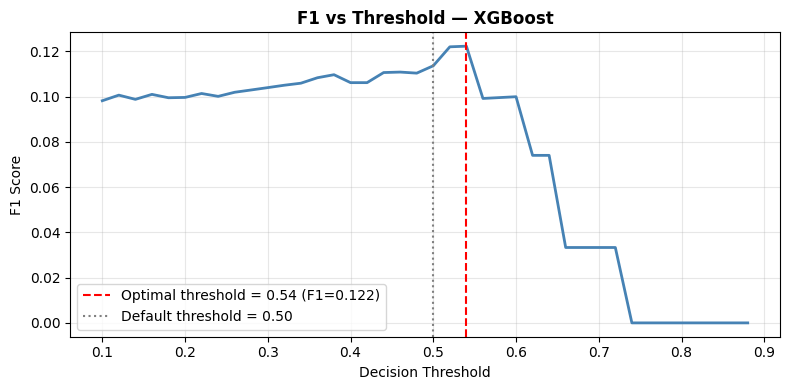

Optimal threshold: 0.54  →  F1 = 0.122
At threshold 0.54:
               precision    recall  f1-score   support

Not disrupted       0.95      0.66      0.78      1001
    Disrupted       0.07      0.44      0.12        59

     accuracy                           0.65      1060
    macro avg       0.51      0.55      0.45      1060
 weighted avg       0.90      0.65      0.74      1060



In [12]:
best_proba = best_row["_y_proba"]
thresholds = np.arange(0.1, 0.9, 0.02)
f1_scores  = [f1_score(y_test, (best_proba >= t).astype(int), zero_division=0) for t in thresholds]

opt_idx = np.argmax(f1_scores)
opt_t   = thresholds[opt_idx]
opt_f1  = f1_scores[opt_idx]

plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_scores, lw=2, color="steelblue")
plt.axvline(opt_t, color="red", linestyle="--", label=f"Optimal threshold = {opt_t:.2f} (F1={opt_f1:.3f})")
plt.axvline(0.5,   color="grey", linestyle=":",  label="Default threshold = 0.50")
plt.xlabel("Decision Threshold")
plt.ylabel("F1 Score")
plt.title(f"F1 vs Threshold — {best_name}", fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/model/threshold_analysis.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Optimal threshold: {opt_t:.2f}  →  F1 = {opt_f1:.3f}")
print(f"At threshold {opt_t:.2f}:")
print(classification_report(
    y_test, (best_proba >= opt_t).astype(int),
    target_names=["Not disrupted", "Disrupted"]
))